# 03 - Dimensionality Reduction: PCA vs LDA

**Goal:** understand what PCA and LDA do to the 128 sensor features, and whether they make a model more robust to drift.
Everything is **untuned**: PCA keeps 95% of the variance (a rule of thumb fixed in advance, *not* chosen using test results)
and LDA uses its maximum of 5 axes (6 gases - 1).

> **Beginner note - the two methods**
> * **PCA** (Principal Component Analysis) is *unsupervised*: it finds the directions in which the data varies most and keeps the top ones.
>   It never looks at the gas labels. 128 numbers become a handful of "principal components".
> * **LDA** (Linear Discriminant Analysis) is *supervised*: it uses the gas labels to find directions that best **separate the gases**
>   (large distance between gas groups, small spread inside each group). With 6 gases it gives at most 5 axes.
>
> Both are *fitted on the training batches only* and then applied unchanged to later batches. If the sensors drift, later data may
> no longer lie in the subspace that was learned. That is what we measure below.

Training set used for the analysis: **batches 1-3** (the P1 protocol).

In [1]:
import os, sys, warnings
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4"); warnings.filterwarnings("ignore")
from pathlib import Path
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import silhouette_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from src.data import load_all, GAS_NAMES
from src.evaluate import evaluate_protocol, summarize, make_pipeline
from src.plotting import apply_style, INK, INK2, GRID, SERIES, MARKERS
apply_style()
FIG = ROOT / "results" / "figures"; RES = ROOT / "results"
X, y, batch = load_all()
tr = batch <= 3
sc = StandardScaler().fit(X[tr])                  # scaler fitted on training batches only
Z = sc.transform(X)
print("training samples:", tr.sum(), "| scaled shape:", Z.shape)

training samples: 3275 | scaled shape: (13910, 128)


## 1. PCA: how many components do we need?

The **cumulative explained variance** curve shows how much of the total variation the first *n* components capture.
We keep as many components as needed to reach **95%**.

components for 90% / 95% / 99% of variance (fitted on B1-3): 8 / 11 / 21   (out of 128)
first 5 components explain: [44.2 22.7  7.5  5.   4.4] %


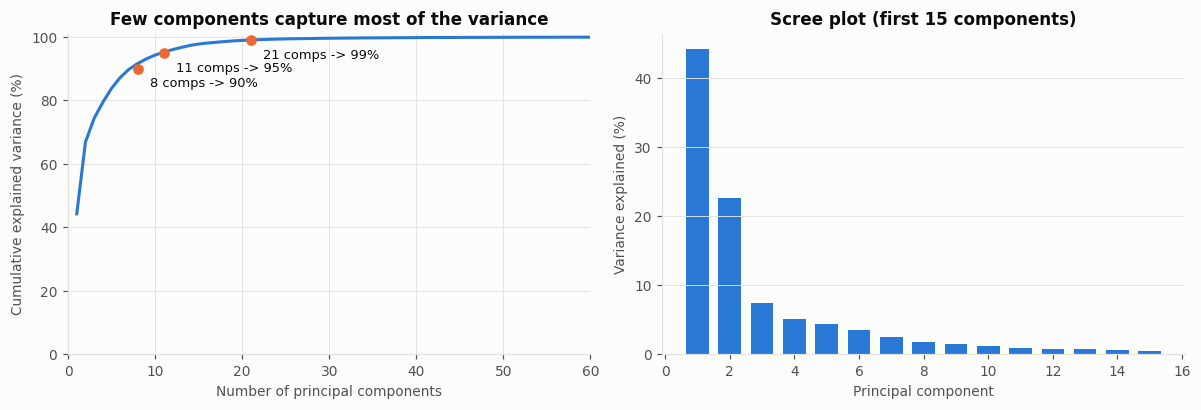

In [2]:
pca_all = PCA(svd_solver="full", random_state=42).fit(Z[tr])
cum = np.cumsum(pca_all.explained_variance_ratio_)
n90, n95, n99 = [int(np.searchsorted(cum, t) + 1) for t in (0.90, 0.95, 0.99)]
print(f"components for 90% / 95% / 99% of variance (fitted on B1-3): {n90} / {n95} / {n99}   (out of 128)")
print("first 5 components explain:", np.round(pca_all.explained_variance_ratio_[:5] * 100, 1), "%")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ax = axes[0]
ax.plot(range(1, 129), cum * 100, color=SERIES[0], lw=2)
for t, n in [(90, n90), (95, n95), (99, n99)]:
    ax.plot([n], [t], "o", color=SERIES[1], ms=6); ax.annotate(f"{n} comps -> {t}%", (n, t), textcoords="offset points", xytext=(8, -12), fontsize=8.5)
ax.set_xlabel("Number of principal components"); ax.set_ylabel("Cumulative explained variance (%)")
ax.set_title("Few components capture most of the variance"); ax.set_ylim(0, 101); ax.set_xlim(0, 60)
ax = axes[1]
ax.bar(range(1, 16), pca_all.explained_variance_ratio_[:15] * 100, color=SERIES[0], width=0.7)
ax.set_xlabel("Principal component"); ax.set_ylabel("Variance explained (%)"); ax.set_title("Scree plot (first 15 components)"); ax.grid(axis="x", visible=False)
fig.tight_layout(); fig.savefig(FIG / "10_pca_variance.png"); plt.show()

## 2. Does later data stay inside the learned subspace? (drift seen through PCA and LDA)

Two measures, both for every batch, using models fitted on **batches 1-3 only**:

* **PCA residual ratio** - PCA keeps a subspace and throws the rest away. For each sample we measure how much of it is
  *left outside* that subspace (reconstruction error). The ratio compares the **median** sample of a batch with the median
  training sample. **1.0 = behaves like the training data; larger = drift is pushing samples out of the learned subspace.**
  (We use the median because a handful of extreme samples can dominate a mean: in batch 9 a single sample carries 95% of the total error.)
* **Silhouette score** of the gas labels in the reduced space (from -1 to +1): how well-separated the gas clusters are. Higher is better.
  We compare the PCA space with the LDA space. Batches 1-3 are in-sample (the model has seen them); batches 4-10 are new.

In [3]:
pca = PCA(n_components=0.95, svd_solver="full", random_state=42).fit(Z[tr])
lda = LDA(n_components=5).fit(Z[tr], y[tr])
print("PCA components kept:", pca.n_components_, "| LDA axes:", lda.n_components)

def residual(Zb): return ((Zb - pca.inverse_transform(pca.transform(Zb))) ** 2).sum(axis=1)   # per-sample error
base_med, base_mean = np.median(residual(Z[tr])), residual(Z[tr]).mean()
rng = np.random.RandomState(42)
def sil(Zr, yb, n=3000):
    return silhouette_score(Zr, yb, sample_size=min(n, len(yb)), random_state=42)

rows = []
for b in range(1, 11):
    m = batch == b
    rows.append({"batch": b, "in_training": b <= 3, "n": int(m.sum()),
                 "pca_residual_ratio": np.median(residual(Z[m])) / base_med,
                 "pca_residual_mean_ratio": residual(Z[m]).mean() / base_mean,        # outlier-sensitive, kept for reference
                 "top_sample_share_of_error": residual(Z[m]).max() / residual(Z[m]).sum(),
                 "silhouette_pca": sil(pca.transform(Z[m]), y[m]),
                 "silhouette_lda": sil(lda.transform(Z[m]), y[m])})
drift = pd.DataFrame(rows); drift.to_csv(RES / "03_subspace_drift.csv", index=False)
display(drift.round(3))

PCA components kept: 11 | LDA axes: 5


,batch,in_training,n,pca_residual_ratio,pca_residual_mean_ratio,top_sample_share_of_error,silhouette_pca,silhouette_lda
0,1,True,445,3.151,1.058,0.058,0.126,0.605
1,2,True,1244,0.987,1.626,0.213,0.052,0.787
2,3,True,1586,0.836,0.493,0.086,0.187,0.818
3,4,False,161,4.908,36.950,0.048,0.096,0.280
4,5,False,197,2.634,1.132,0.221,0.338,0.708
5,6,False,2300,3.662,0.751,0.004,0.109,0.451
6,7,False,3613,3.758,0.949,0.002,-0.000,0.191
7,8,False,294,2.801,1.087,0.419,0.090,0.181
8,9,False,470,2.403,10.530,0.955,0.556,0.427
9,10,False,3600,3.345,6.128,0.013,-0.097,-0.070


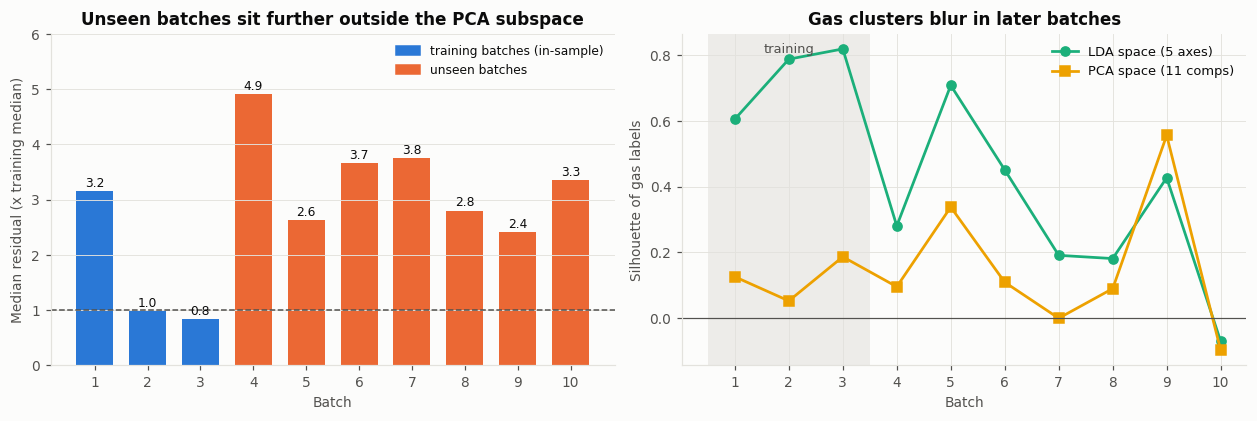

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))
ax = axes[0]
cols = [SERIES[0] if b <= 3 else SERIES[1] for b in drift.batch]
ax.bar(drift.batch, drift.pca_residual_ratio, color=cols, width=0.7)
ax.axhline(1, color=INK2, lw=1, ls="--")
for b, v in zip(drift.batch, drift.pca_residual_ratio): ax.text(b, v + 0.08, f"{v:.1f}", ha="center", fontsize=8)
ax.set_xticks(range(1, 11)); ax.set_xlabel("Batch"); ax.set_ylabel("Median residual (x training median)"); ax.set_ylim(0, 6)
ax.set_title("Unseen batches sit further outside the PCA subspace"); ax.grid(axis="x", visible=False)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=SERIES[0], label="training batches (in-sample)"), Patch(color=SERIES[1], label="unseen batches")], frameon=False, fontsize=8, loc="upper right")
ax = axes[1]
ax.plot(drift.batch, drift.silhouette_lda, color=SERIES[2], marker="o", lw=1.8, label="LDA space (5 axes)")
ax.plot(drift.batch, drift.silhouette_pca, color=SERIES[3], marker="s", lw=1.8, label=f"PCA space ({pca.n_components_} comps)")
ax.axvspan(0.5, 3.5, color=GRID, alpha=0.6, lw=0); ax.text(2, ax.get_ylim()[1] * 0.97, "training", ha="center", va="top", fontsize=8.5, color=INK2)
ax.axhline(0, color=INK2, lw=0.8)
ax.set_xticks(range(1, 11)); ax.set_xlabel("Batch"); ax.set_ylabel("Silhouette of gas labels")
ax.set_title("Gas clusters blur in later batches"); ax.legend(frameon=False, fontsize=8.5)
fig.tight_layout(); fig.savefig(FIG / "11_subspace_drift.png"); plt.show()

## 3. What does LDA's view of the data look like?

LDA fitted on batches 1-3 is applied unchanged to later batches. Each panel plots the first two LDA axes, coloured by gas.
In the training panel the six gases are well separated; the later panels show how the clusters **move and blur** with drift.

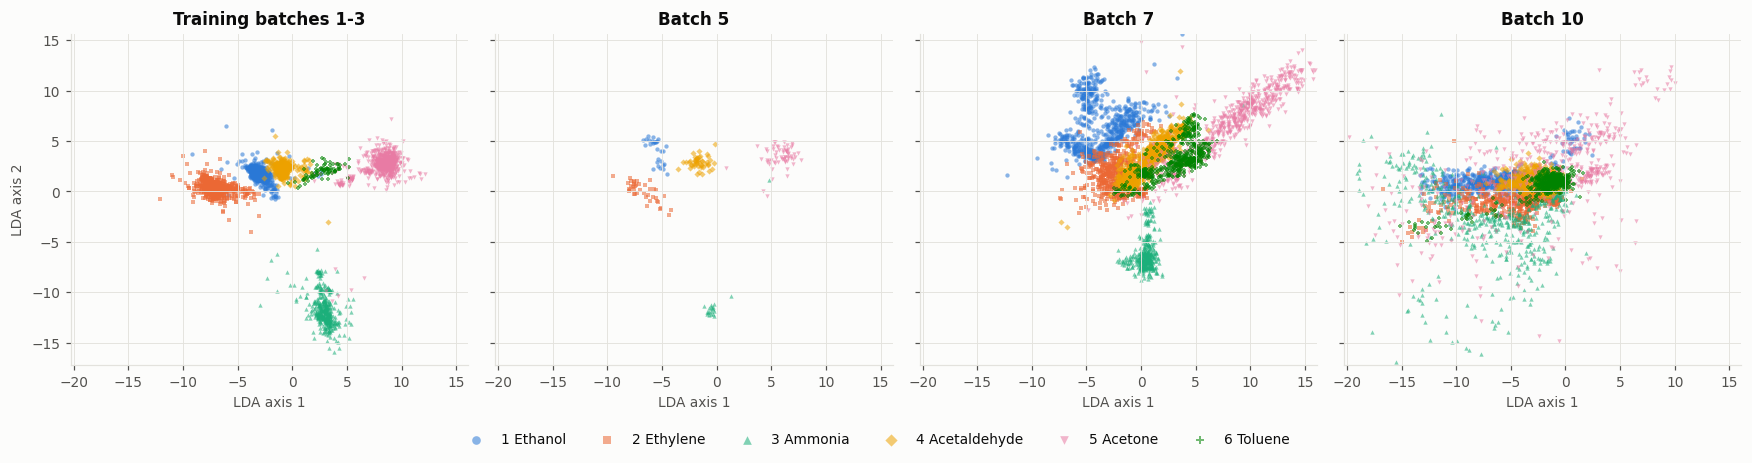

In [5]:
P = lda.transform(Z)
panels = [("Training batches 1-3", batch <= 3), ("Batch 5", batch == 5), ("Batch 7", batch == 7), ("Batch 10", batch == 10)]
colors = {g: SERIES[g - 1] for g in range(1, 7)}; marks = {g: MARKERS[g - 1] for g in range(1, 7)}
fig, axes = plt.subplots(1, 4, figsize=(16, 3.9), sharex=True, sharey=True)
lo, hi = np.percentile(P[:, :2], 1, axis=0), np.percentile(P[:, :2], 99, axis=0); pad = 0.15 * (hi - lo)
for ax, (title, m) in zip(axes, panels):
    for g in range(1, 7):
        s = m & (y == g)
        ax.scatter(P[s, 0], P[s, 1], s=8, alpha=0.55, linewidths=0, color=colors[g], marker=marks[g], label=f"{g} {GAS_NAMES[g]}")
    ax.set_title(title); ax.set_xlabel("LDA axis 1")
    ax.set_xlim(lo[0] - pad[0], hi[0] + pad[0]); ax.set_ylim(lo[1] - pad[1], hi[1] + pad[1])
axes[0].set_ylabel("LDA axis 2")
h, l = axes[0].get_legend_handles_labels(); fig.legend(h, l, loc="lower center", ncol=6, frameon=False, markerscale=2, bbox_to_anchor=(0.5, -0.08))
fig.tight_layout(); fig.savefig(FIG / "12_lda_projection.png"); plt.show()

## 4. Does PCA or LDA make a classifier more robust to drift?

Default SVM and kNN, scaling only (`raw`) vs scaling + PCA (95% variance) vs scaling + LDA (5 axes), under protocols P1, P2, P3.
All steps are refitted on the training batches of each split, so nothing leaks. **No settings are tuned.**

In [6]:
models = {"SVM": SVC(), "kNN": KNeighborsClassifier()}
parts = []
for name, est in models.items():
    for variant in ["raw", "PCA", "LDA"]:
        for proto in ["P1", "P2", "P3"]:
            parts.append(evaluate_protocol(est, X, y, batch, proto, variant, name=name))
res = pd.concat(parts, ignore_index=True)
res.to_csv(RES / "03_variants_results.csv", index=False)
summ = summarize(res); summ.to_csv(RES / "03_variants_summary.csv", index=False)
display(summ[summ.protocol == "P1"].round(3).reset_index(drop=True))

,model,variant,protocol,n_test_batches,mean_accuracy,mean_macro_f1,weighted_accuracy,weighted_macro_f1,min_macro_f1
0,SVM,raw,P1,7.0,0.705,0.690,0.608,0.579,0.431
1,SVM,PCA,P1,7.0,0.666,0.660,0.563,0.552,0.450
2,SVM,LDA,P1,7.0,0.666,0.614,0.602,0.556,0.404
3,kNN,raw,P1,7.0,0.615,0.609,0.581,0.558,0.464
4,kNN,PCA,P1,7.0,0.601,0.594,0.571,0.547,0.441
5,kNN,LDA,P1,7.0,0.640,0.610,0.559,0.532,0.349


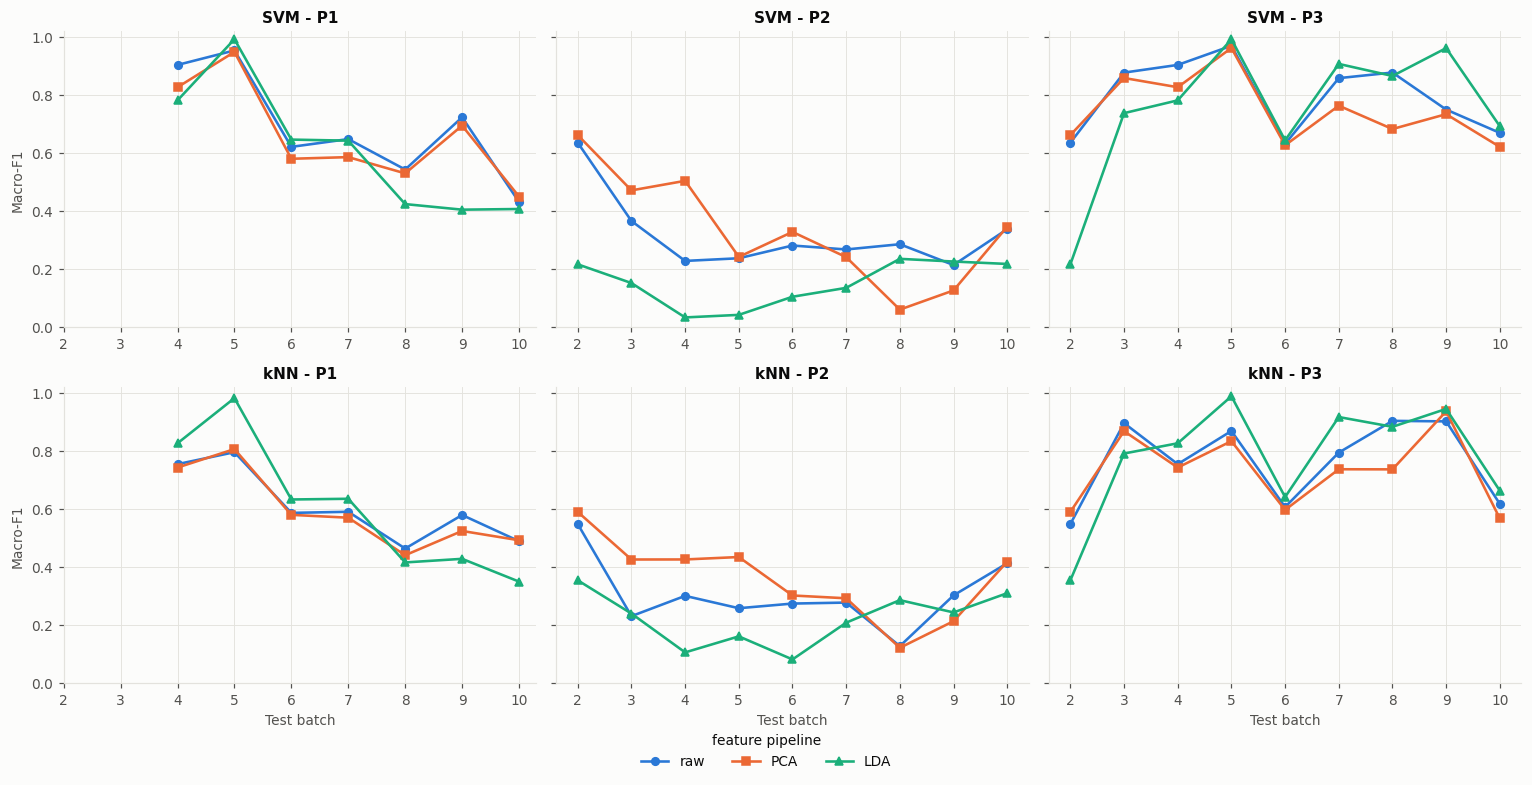

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
vcol = {"raw": SERIES[0], "PCA": SERIES[1], "LDA": SERIES[2]}; vmk = {"raw": "o", "PCA": "s", "LDA": "^"}
for i, name in enumerate(models):
    for j, proto in enumerate(["P1", "P2", "P3"]):
        ax = axes[i, j]
        for v in ["raw", "PCA", "LDA"]:
            d = res[(res.model == name) & (res.protocol == proto) & (res.variant == v)]
            ax.plot(d.test_batch, d.macro_f1, color=vcol[v], marker=vmk[v], ms=5, lw=1.7, label=v if (i, j) == (0, 0) else None)
        ax.set_title(f"{name} - {proto}", fontsize=10); ax.set_xticks(range(2, 11)); ax.set_ylim(0, 1.02)
        if i == 1: ax.set_xlabel("Test batch")
        if j == 0: ax.set_ylabel("Macro-F1")
h, l = axes[0, 0].get_legend_handles_labels(); fig.legend(h, l, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.02), title="feature pipeline")
fig.tight_layout(rect=(0, 0.03, 1, 1)); fig.savefig(FIG / "13_pca_lda_downstream.png"); plt.show()

### Robustness check (not a tuning step)
Is the conclusion an accident of choosing exactly 95%? We repeat SVM/P1 with 90% and 99% of the variance.
The 95% value stays the pre-declared default; this table only shows how sensitive the result is.

In [8]:
rows = []
for var in [0.90, 0.95, 0.99]:
    d = evaluate_protocol(SVC(), X, y, batch, "P1", "PCA", name="SVM", pca_variance=var)
    rows.append({"pca_variance": var, "mean_accuracy": d.accuracy.mean(), "mean_macro_f1": d.macro_f1.mean()})
sens = pd.DataFrame(rows); sens.to_csv(RES / "03_pca_sensitivity.csv", index=False); display(sens.round(3))

,pca_variance,mean_accuracy,mean_macro_f1
0,0.90,0.615,0.617
1,0.95,0.666,0.660
2,0.99,0.700,0.686


## 5. Key takeaways

All classifiers are default-setting SVM and kNN; PCA keeps 95% of the variance (fixed in advance) and LDA uses 5 axes. These are preliminary, untuned results.

| Mean over test batches (P1: train B1-3) | SVM acc / macro-F1 | kNN acc / macro-F1 |
|---|---|---|
| Raw (scaling only, 128 features) | 70.5% / 69.0% | 61.5% / 60.9% |
| PCA (11 components) | 66.6% / 66.0% | 60.1% / 59.4% |
| LDA (5 axes) | 66.6% / 61.4% | 64.0% / 61.0% |

1. **PCA compresses the data hugely.** On batches 1-3, **11 components** (of 128) keep 95% of the variance (8 for 90%, 21 for 99%). The first component alone holds 44.2% and the first two 66.9%, which reflects the strong redundancy found in notebook 01.
2. **PCA costs little on the later batches; LDA costs a lot.** On the far batches (8-10, P1), PCA stays close to raw scaling (SVM macro-F1 55.8% vs 56.6%; kNN 48.6% vs 51.1%), while LDA drops by about 11-15 points (SVM 41.2%, kNN 39.8%). LDA is competitive on early batches (kNN 90.5% vs 77.6% on batches 4-5; SVM 88.8% vs 93.0%). **LDA uses the gas labels to fit the class structure of the training period, so it is more tightly tied to that period and breaks down as the sensors drift.**
3. **Why: the LDA space stops separating the gases.** Silhouette score of the gas labels in the LDA space is 0.60-0.82 on the training batches, then 0.28 (B4), 0.71 (B5), 0.45 (B6), 0.19 (B7), 0.18 (B8), 0.43 (B9) and **-0.07 on batch 10**, i.e. clusters overlap completely. The LDA projection plot shows the same: Ammonia and Acetone move and spread out by batch 7, and batch 10 is smeared. PCA is poor at separating gases throughout (silhouette at most 0.19 on training data).
4. **Unseen batches fall outside the PCA subspace, but not as a clean time trend.** The median sample's reconstruction error is 0.8-1.0x the training median for batches 2-3, versus 2.4-4.9x for every unseen batch. Batch 1, although in the training set, is also 3.2x (it is only 14% of the training data, so the subspace is dominated by batches 2-3). So the effect is real but not simply "later is worse". A mean-based version of this measure is dominated by a few outlier samples (in batch 9, one sample carries 95% of the total error), which is why the median is used.
5. **LDA needs enough, recent training data.** With a tiny training set (P2, 445 samples of batch 1 only) LDA collapses (SVM macro-F1 15.1% vs 31.6% raw). In the rolling protocol P3, excluding the first split (train on B1 only), LDA matches or beats raw scaling (SVM 82.3% vs 81.8%; kNN 83.3% vs 79.4% macro-F1 on batches 3-10), whereas PCA is 4-6 points lower.
6. **The PCA result is not an accident of the 95% choice.** SVM P1 macro-F1 is 61.7% (90% variance), 66.0% (95%) and 68.6% (99%); more components move the score towards raw scaling (69.0%). This is only a sensitivity check, not a tuned selection.
7. **Bottom line for the review:** neither PCA nor LDA is a consistent drift fix with default settings. PCA gives a compact 11-feature representation at a small cost; LDA helps on near-term data but is the least drift-robust choice on distant batches. This sets up the model comparison (Step 4) and the drift-mitigation experiments later.